# 01 · Exploración de la venta diaria de tiendas
Antes de armar el modelo de pronóstico: cómo se comporta la venta por día, semana, mes y tienda, y qué tan bien proyecta
la regla simple actual (mismo día del año pasado × crecimiento reciente). Todo sale de los archivos locales de `datos/`:
**no consulta la base** (para traer datos nuevos: `cargar(actualizar=True)` o `python datos.py`).
Se usa **solo el reporte interno** (data oficial); ContaNet no entra al análisis ni al entrenamiento.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as mt
from datos import cargar

plt.rcParams.update({"figure.figsize": (12, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .25, "font.size": 10})
NARANJA, GRIS, CAFE = "#ec8416", "#b8a79a", "#5c1a07"
miles = mt.FuncFormatter(lambda v, _: f"{v/1e3:,.0f} mil")

ventas, metas, info = cargar()
info

{'descargado': '2026-10-02T09:55:49',
 'hasta_interno': '2026-09-25',
 'hasta_contanet': '2026-10-01',
 'filas': 75227,
 'venta_interno': 20974761.04}

## 1. Cuadre de la data
El total del reporte interno debe ser **S/ 20,974,761.04** (igual a los Excel del Power BI).

In [2]:
print(f"Reporte interno: S/ {ventas.venta.sum():,.2f}  ·  {ventas.fecha.min():%d/%m/%Y} a {ventas.fecha.max():%d/%m/%Y}")
(ventas.groupby("tienda")
   .agg(desde=("fecha", "min"), hasta=("fecha", "max"), dias=("fecha", "nunique"), venta=("venta", "sum"))
   .sort_values("venta", ascending=False).style.format({"venta": "S/ {:,.0f}", "desde": "{:%d/%m/%Y}", "hasta": "{:%d/%m/%Y}"}))

Reporte interno: S/ 20,974,761.04  ·  02/01/2025 a 25/09/2026


,desde,hasta,dias,venta
tienda,,,,
Sol de Oro,02/01/2025,25/09/2026,631,"S/ 5,548,187"
Trinidad,02/01/2025,25/09/2026,632,"S/ 4,871,102"
Surco,02/01/2025,25/09/2026,609,"S/ 3,231,792"
Tupac,02/01/2025,25/09/2026,631,"S/ 2,689,643"
Abancay,07/04/2025,25/09/2026,516,"S/ 1,851,225"
Pana Norte,02/01/2025,25/09/2026,609,"S/ 1,455,642"
Jose Granda,02/01/2025,25/09/2026,564,"S/ 1,327,170"


## 2. Venta diaria total (todas las tiendas)
Línea fina = cada día; línea gruesa = promedio de 7 días.

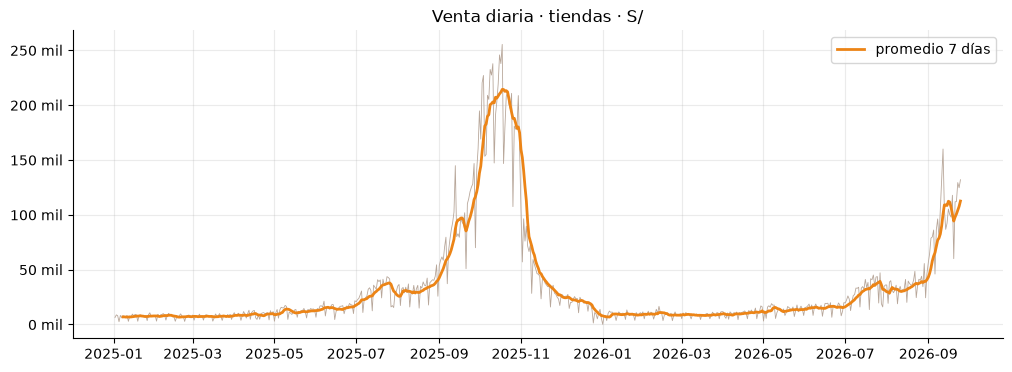

In [3]:
dia = ventas.groupby("fecha").venta.sum().asfreq("D", fill_value=0)
fig, ax = plt.subplots()
ax.plot(dia.index, dia, color=GRIS, lw=.6)
ax.plot(dia.index, dia.rolling(7).mean(), color=NARANJA, lw=2, label="promedio 7 días")
ax.yaxis.set_major_formatter(miles); ax.set_title("Venta diaria · tiendas · S/"); ax.legend(); plt.show()

## 3. 2026 contra 2025, mes a mes
Meses completos; el mes en curso se compara hasta el mismo día.

In [4]:
ultimo = dia.index.max()
m = dia.to_frame("venta"); m["anio"], m["mes"], m["d"] = m.index.year, m.index.month, m.index.day
corte = lambda x: x[(x.mes < ultimo.month) | ((x.mes == ultimo.month) & (x.d <= ultimo.day))]
t = corte(m).pivot_table(index="mes", columns="anio", values="venta", aggfunc="sum")
t["crecimiento"] = t[2026] / t[2025] - 1
t.style.format({2025: "S/ {:,.0f}", 2026: "S/ {:,.0f}", "crecimiento": "{:+.1%}"}, na_rep="—")

anio,2025,2026,crecimiento
mes,,,
1,"S/ 218,018","S/ 272,061",+24.8%
2,"S/ 206,898","S/ 259,074",+25.2%
3,"S/ 225,175","S/ 269,788",+19.8%
4,"S/ 270,477","S/ 311,518",+15.2%
5,"S/ 366,073","S/ 400,231",+9.3%
6,"S/ 447,846","S/ 466,657",+4.2%
7,"S/ 910,873","S/ 940,880",+3.3%
8,"S/ 1,021,548","S/ 1,082,436",+6.0%
9,"S/ 2,137,621","S/ 2,442,927",+14.3%


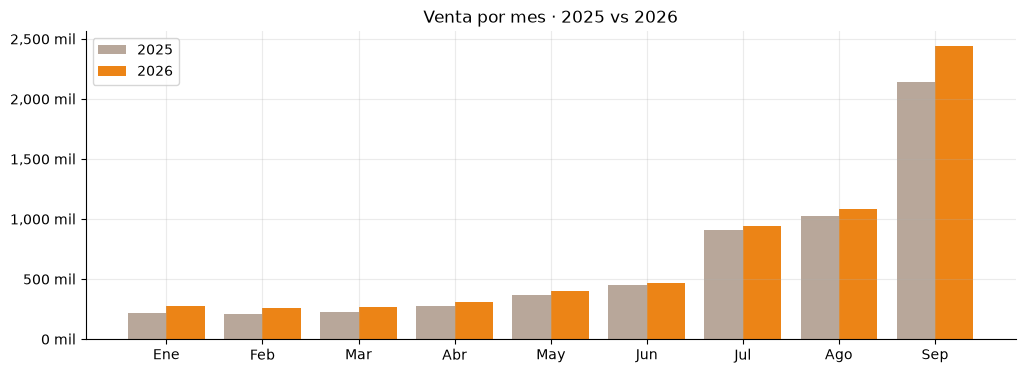

In [5]:
fig, ax = plt.subplots()
x = np.arange(len(t)); ax.bar(x - .2, t[2025], .4, color=GRIS, label="2025"); ax.bar(x + .2, t[2026], .4, color=NARANJA, label="2026")
ax.set_xticks(x, ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"][:len(t)])
ax.yaxis.set_major_formatter(miles); ax.set_title("Venta por mes · 2025 vs 2026"); ax.legend(); plt.show()

## 4. Día de la semana
Índice = venta del día ÷ promedio de su semana (1.00 = día promedio). Muestra qué días pesan más.

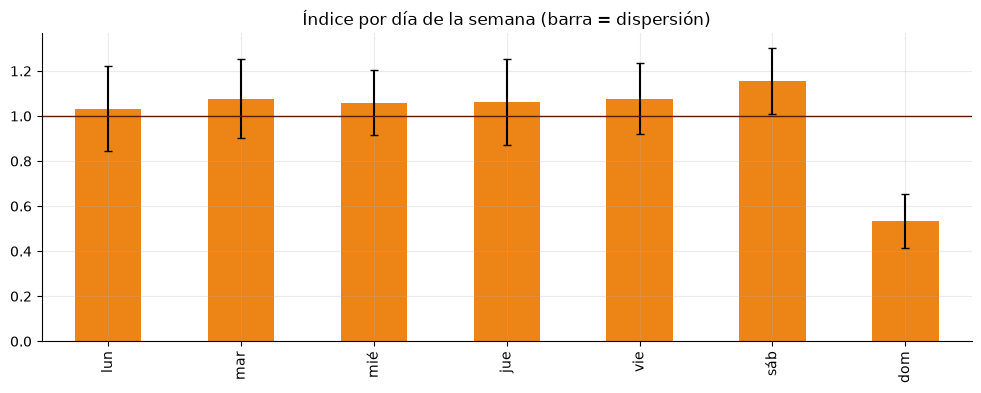

,mean,std
lun,1.03,0.19
mar,1.08,0.18
mié,1.06,0.14
jue,1.06,0.19
vie,1.08,0.16
sáb,1.16,0.15
dom,0.53,0.12


In [6]:
s = dia[dia > 0].to_frame("venta"); s["semana"] = s.index.to_period("W"); s["dia"] = s.index.dayofweek
s["indice"] = s.venta / s.groupby("semana").venta.transform("mean")
ind = s.groupby("dia").indice.agg(["mean", "std"]); ind.index = ["lun","mar","mié","jue","vie","sáb","dom"]
ax = ind["mean"].plot.bar(color=NARANJA, yerr=ind["std"], capsize=3, title="Índice por día de la semana (barra = dispersión)")
ax.axhline(1, color=CAFE, lw=1); plt.show(); ind.round(2)

## 5. Día del mes (quincenas y fin de mes)
Índice del día del mes vs el promedio de su mes.

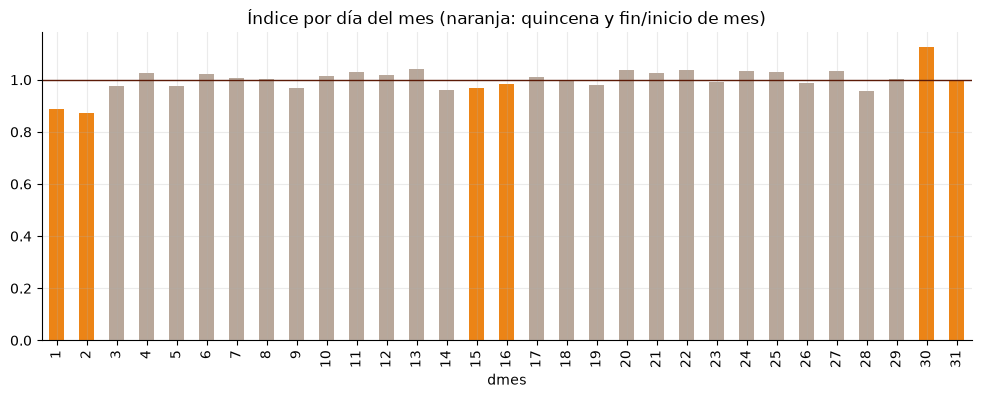

In [7]:
s["mes"] = s.index.to_period("M"); s["dmes"] = s.index.day
s["ind_mes"] = s.venta / s.groupby("mes").venta.transform("mean")
dm = s.groupby("dmes").ind_mes.mean()
ax = dm.plot.bar(color=[NARANJA if d in (1, 2, 15, 16, 30, 31) else GRIS for d in dm.index], title="Índice por día del mes (naranja: quincena y fin/inicio de mes)")
ax.axhline(1, color=CAFE, lw=1); plt.show()

## 6. Tiendas: tamaño y crecimiento

In [8]:
tm = ventas.assign(anio=ventas.fecha.dt.year, mes=ventas.fecha.dt.month, d=ventas.fecha.dt.day)
tm = corte(tm).pivot_table(index="tienda", columns="anio", values="venta", aggfunc="sum")
tm["crecimiento"] = tm[2026] / tm[2025] - 1; tm["% 2026"] = tm[2026] / tm[2026].sum()
tm.sort_values(2026, ascending=False).style.format({2025: "S/ {:,.0f}", 2026: "S/ {:,.0f}", "crecimiento": "{:+.1%}", "% 2026": "{:.1%}"}, na_rep="—")

anio,2025,2026,crecimiento,% 2026
tienda,,,,
Sol de Oro,"S/ 1,567,805","S/ 1,736,913",+10.8%,26.9%
Trinidad,"S/ 1,395,084","S/ 1,442,390",+3.4%,22.4%
Surco,"S/ 813,427","S/ 1,001,125",+23.1%,15.5%
Tupac,"S/ 739,051","S/ 865,265",+17.1%,13.4%
Abancay,"S/ 469,218","S/ 591,235",+26.0%,9.2%
Pana Norte,"S/ 403,741","S/ 451,797",+11.9%,7.0%
Jose Granda,"S/ 416,202","S/ 356,847",-14.3%,5.5%


## 7. Línea base: la regla simple actual
**Pronóstico = venta del mismo día de la semana del año pasado (364 días antes) × crecimiento de las últimas 4 semanas**
(últimas 4 semanas de este año ÷ las mismas 4 semanas del año pasado). Se prueba día por día del 01/07 al 25/09/2026 (último día del reporte interno)
usando solo lo que se sabía antes de ese día. **El modelo tiene que ganarle a esta regla.**

In [9]:
def regla(f):
    ly = dia.get(f - pd.Timedelta(days=364))
    num = dia[f - pd.Timedelta(days=28): f - pd.Timedelta(days=1)].sum()
    den = dia[f - pd.Timedelta(days=392): f - pd.Timedelta(days=365)].sum()
    return ly * num / den if ly and den else np.nan

prueba = pd.DataFrame({"real": dia["2026-07-01":]})
prueba = prueba[prueba.real > 0]
prueba["pronostico"] = [regla(f) for f in prueba.index]
prueba["error"] = (prueba.pronostico - prueba.real).abs() / prueba.real
print(f"Error medio: {prueba.error.mean():.1%}  ·  precisión: {1 - prueba.error.mean():.1%}  ·  días: {prueba.error.notna().sum()}")
prueba.groupby(prueba.index.month).error.mean().rename(lambda x: ["Jul","Ago","Sep"][x-7]).map("{:.1%}".format)

Error medio: 12.3%  ·  precisión: 87.7%  ·  días: 87


fecha
Jul    16.6%
Ago    11.0%
Sep     8.7%
Name: error, dtype: str

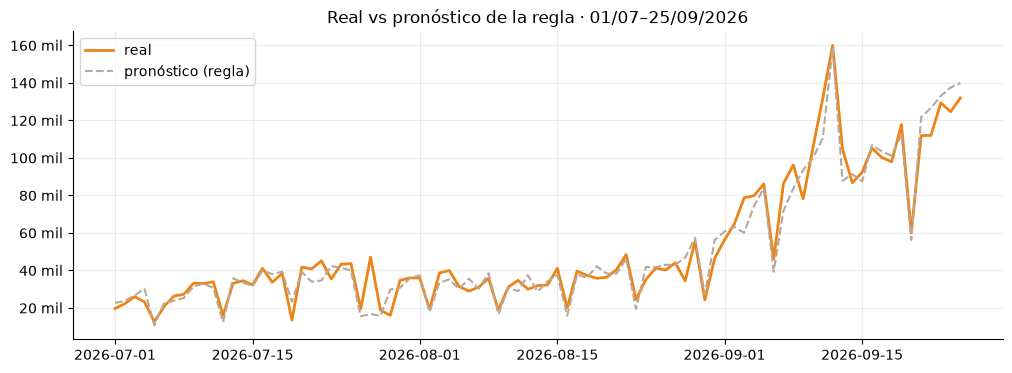

,real,pronostico,error
fecha,,,
2026-07-29 00:00:00,"S/ 15,922","S/ 29,782",87.0%
2026-07-19 00:00:00,"S/ 13,472","S/ 23,200",72.2%
2026-07-27 00:00:00,"S/ 47,038","S/ 16,686",64.5%
2026-08-28 00:00:00,"S/ 34,353","S/ 46,793",36.2%
2026-07-04 00:00:00,"S/ 23,132","S/ 30,185",30.5%
2026-08-12 00:00:00,"S/ 29,923","S/ 37,346",24.8%
2026-09-03 00:00:00,"S/ 78,618","S/ 60,011",23.7%
2026-07-22 00:00:00,"S/ 45,048","S/ 34,535",23.3%


In [10]:
fig, ax = plt.subplots()
ax.plot(prueba.index, prueba.real, color=NARANJA, lw=2, label="real")
ax.plot(prueba.index, prueba.pronostico, color=GRIS, lw=1.5, ls="--", label="pronóstico (regla)")
ax.yaxis.set_major_formatter(miles); ax.set_title("Real vs pronóstico de la regla · 01/07–25/09/2026"); ax.legend(); plt.show()
prueba.sort_values("error", ascending=False).head(8).style.format({"real": "S/ {:,.0f}", "pronostico": "S/ {:,.0f}", "error": "{:.1%}"})

## Qué mirar
- **Sección 4 y 5:** si el día de la semana y la quincena mueven mucho la venta, el modelo debe usarlos como variables.
- **Sección 7:** los días con mayor error (feriados, fechas que cambiaron de día de la semana) dicen qué le falta a la regla.
- Siguiente cuaderno: `02_modelo.ipynb`, con las variables y la comparación contra esta línea base.